<a href="https://colab.research.google.com/github/tanishkshindepatil01/ai-text-analytics-coursework-team16-task1/blob/main/AI%26TA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Medical Question Answering — PubMedQA

**Objective:** Analyse how different text representations and AI methods affect the quality of answers to medical questions.

**Dataset:** PubMedQA (expert-annotated subset, 1,000 examples)  
**Task type:** 3-class answer classification (yes / no / maybe)

## Step 0 — Install & Import

We will install and import all essential machine learning and NLP libraries, then set global random seeds to ensure fully reproducible results.

In [1]:
import os
import re
import json
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score
)

try:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification
    )
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SBERT_OK = True
except Exception:
    SBERT_OK = False

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All main libraries imported successfully.")
print(f"Random seed set to {RANDOM_SEED}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"SentenceTransformers available: {SBERT_OK}")

All main libraries imported successfully.
Random seed set to 42
Transformers available: True
SentenceTransformers available: True


In [2]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
print("imbalanced-learn installed and imported.")

imbalanced-learn installed and imported.


The environment setup is complete and we have verified that PyTorch and Hugging Face Transformers are active and available.

## Step 1 — Load & Explore Data

### 1.1 Loading & Previewing the JSON

We will load the raw JSON dataset from disk and print a quick preview of a single record to inspect the data structure.

In [3]:
DATA_PATH = "/content/data/ori_pqal.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

first_key = list(data.keys())[0]
print(f"\nExample PMID: {first_key}")
print(json.dumps(data[first_key], indent=2)[:800])

Total records: 1000

Example PMID: 21645374
{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madaga


All 1,000 records loaded successfully. Each record contains a medical question, context paragraphs, a long answer, and a final decision label.

### 1.2 Converting to a Pandas DataFrame

We will iterate through the raw JSON and convert it into a structured Pandas DataFrame while checking for any missing values.

In [4]:
rows = []
for pmid, info in data.items():
    contexts = info.get("CONTEXTS", [])
    rows.append({
        "pmid": pmid,
        "question": info.get("QUESTION", ""),
        "context_list": contexts,
        "context": " ".join(contexts) if isinstance(contexts, list) else str(contexts),
        "long_answer": info.get("LONG_ANSWER", ""),
        "label": str(info.get("final_decision", "")).lower().strip()
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


DataFrame shape: (1000, 6)
Columns: ['pmid', 'question', 'context_list', 'context', 'long_answer', 'label']

Missing values:
pmid            0
question        0
context_list    0
context         0
long_answer     0
label           0
dtype: int64


The DataFrame contains 1,000 rows and 6 columns with absolutely zero missing values.

### 1.3 Checking Label Distribution

We will run a quick check on our target variable to see how the three labels are distributed across the dataset.

In [5]:
print(f"\nLabel distribution:")
print(df["label"].value_counts())


Label distribution:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64


The dataset is imbalanced with 552 'yes', 338 'no', and 110 'maybe' labels, which will be an important factor in our modelling strategy.

### 1.4 Feature Engineering for Exploration

We will calculate word counts for our questions, contexts, and long answers so we can visualise their distributions.

In [6]:
df["question_len"] = df["question"].str.split().str.len()
df["context_len"] = df["context"].str.split().str.len()
df["long_answer_len"] = df["long_answer"].str.split().str.len()
df["num_contexts"] = df["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Feature columns added: question_len, context_len, long_answer_len, num_contexts")

Feature columns added: question_len, context_len, long_answer_len, num_contexts


The DataFrame now has the raw length and sentence count features needed for our visualisation grid.

### 1.5 Data Exploration Visualisations

We will build a 6-panel visualisation grid showing label distribution, text length histograms by label, context sentence counts, boxplots, and a scatter plot.

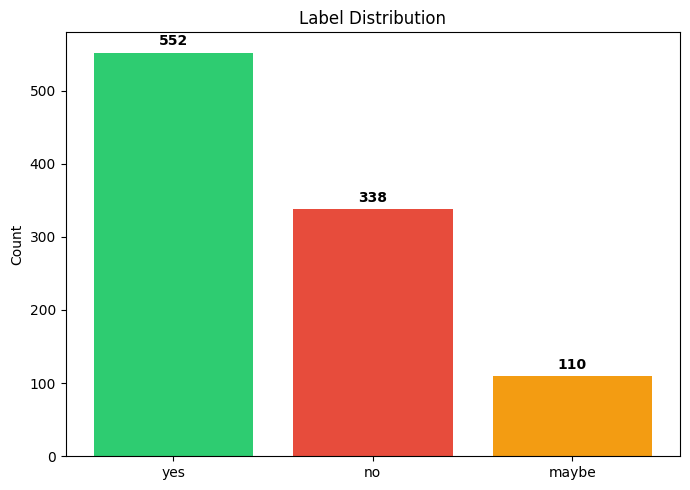

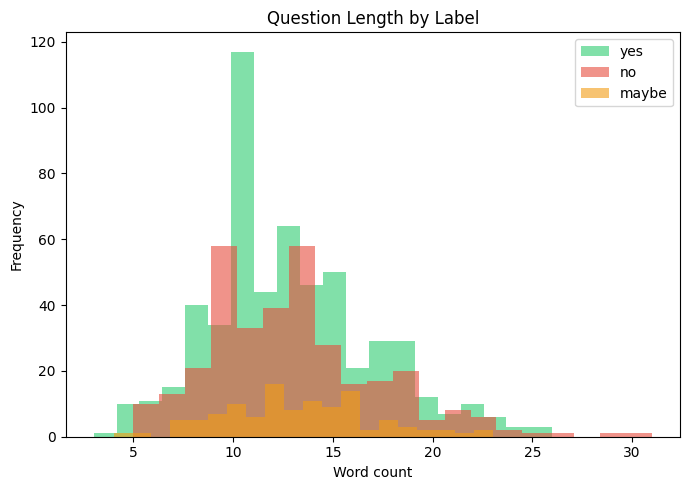

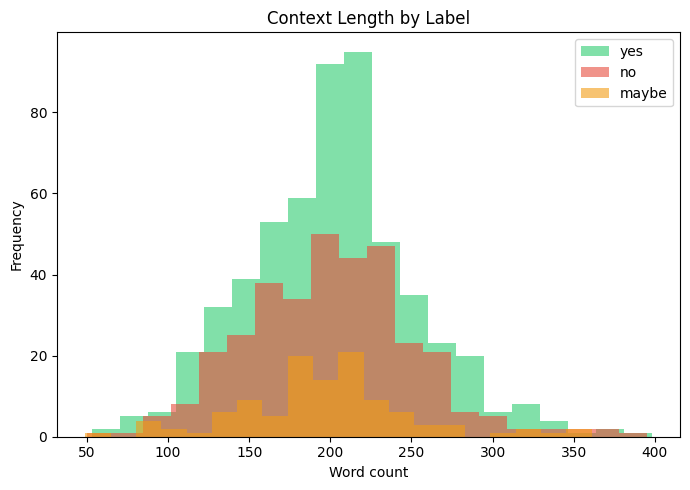

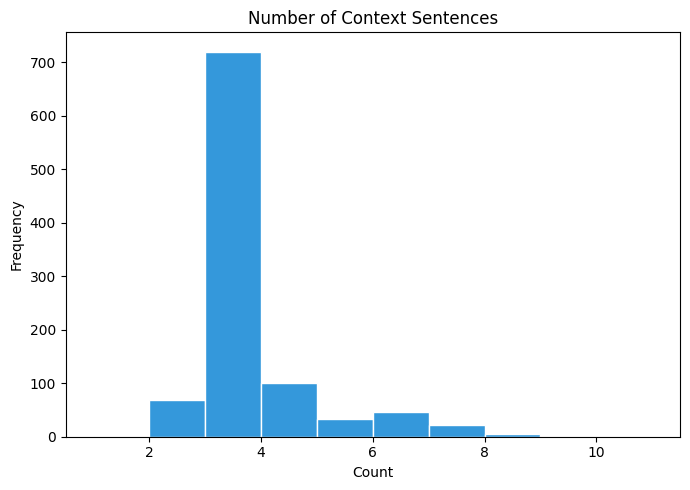

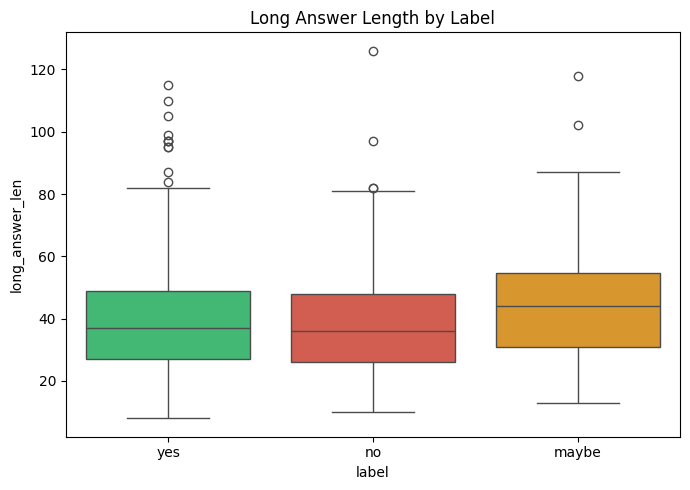

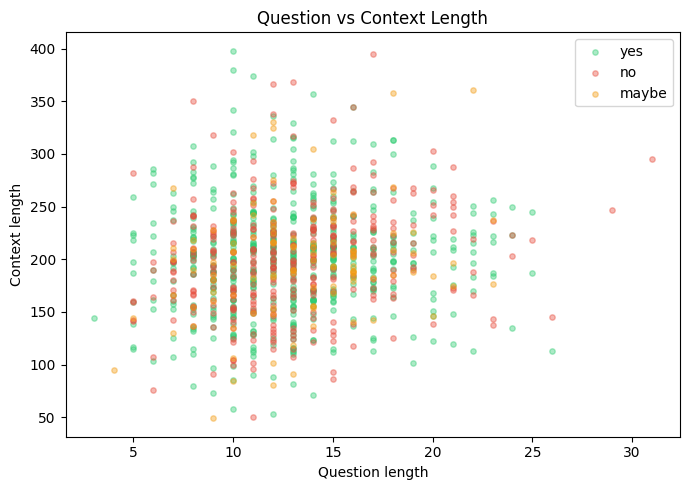

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

colors = {"yes": "#2ecc71", "no": "#e74c3c", "maybe": "#f39c12"}

plt.figure(figsize=(7, 5))
label_counts = df["label"].value_counts()
plt.bar(label_counts.index, label_counts.values,
        color=[colors.get(lab, "#3498db") for lab in label_counts.index])
plt.title("Label Distribution")
plt.ylabel("Count")

for i, (lab, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    plt.text(i, cnt + 10, str(cnt), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_1_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["question_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Question Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_2_question_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["context_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Context Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_3_context_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(df["num_contexts"], bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Number of Context Sentences")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_4_num_context_sentences.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="label",
    y="long_answer_len",
    order=["yes", "no", "maybe"],
    palette=[colors["yes"], colors["no"], colors["maybe"]]
)
plt.title("Long Answer Length by Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_5_long_answer_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]
    plt.scatter(
        subset["question_len"],
        subset["context_len"],
        alpha=0.4,
        label=lab,
        color=colors[lab],
        s=15
    )

plt.title("Question vs Context Length")
plt.xlabel("Question length")
plt.ylabel("Context length")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_6_question_vs_context_length.png"), dpi=300, bbox_inches="tight")
plt.show()

The visualisations clearly show the label imbalance and how context lengths are distributed, giving us a solid understanding of the dataset before preprocessing.

### 1.6 Descriptive Statistics Summary

We will print a rounded table of descriptive statistics to get the exact numerical summaries for our text lengths.

In [8]:
print("\nDescriptive statistics:")
display(df[["question_len", "context_len", "long_answer_len", "num_contexts"]].describe().round(1))


Descriptive statistics:


,question_len,context_len,long_answer_len,num_contexts
count,1000.0,1000.0,1000.0,1000.0
mean,12.9,200.2,39.7,3.4
std,4.1,51.8,17.2,1.1
min,3.0,49.0,8.0,1.0
25%,10.0,166.8,27.0,3.0
50%,13.0,200.5,37.0,3.0
75%,15.0,228.0,49.0,3.0
max,31.0,398.0,126.0,9.0


The average context length is roughly 200 words with a max of 398, confirming we are well within manageable tokeniser limits.

## Step 2 — Preprocessing & Feature Engineering

### 2.1 Text Cleaning

We will define a custom cleaning function to lowercase all text and strip out irregular punctuation, then apply it to the main text columns.

In [9]:
df_model = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\-\?\.,:;/%()]", " ", text)
    return text.strip()

df_model["question_clean"] = df_model["question"].apply(clean_text)
df_model["context_clean"] = df_model["context"].apply(clean_text)
df_model["long_answer_clean"] = df_model["long_answer"].apply(clean_text)

print(f"Text cleaning complete. Columns: {[c for c in df_model.columns if 'clean' in c]}")

Text cleaning complete. Columns: ['question_clean', 'context_clean', 'long_answer_clean']


Text cleaning is complete and our core text columns are now fully standardised for consistent downstream processing.

### 2.2 Input Variants & Label Encoding

We will generate three distinct input text variants (question only, question + context, and question + context + answer) and encode the labels as integers.

In [10]:
df_model["text_q_only"] = "question: " + df_model["question_clean"]
df_model["text_q_ctx"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
)
df_model["text_q_ctx_ans"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
    + " answer: " + df_model["long_answer_clean"]
)

label2id = {"no": 0, "maybe": 1, "yes": 2}
id2label = {0: "no", 1: "maybe", 2: "yes"}
df_model["label_id"] = df_model["label"].map(label2id)
df_model["question_len"] = df_model["question_clean"].apply(lambda x: len(x.split()))
df_model["context_len"] = df_model["context_clean"].apply(lambda x: len(x.split()))
df_model["long_answer_len"] = df_model["long_answer_clean"].apply(lambda x: len(x.split()))
df_model["num_contexts"] = df_model["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 1)

assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found!"

print(f"Input variants created. Shape: {df_model.shape}")
print(f"Label distribution: {df_model['label_id'].value_counts().sort_index().to_dict()}")

Input variants created. Shape: (1000, 17)
Label distribution: {0: 338, 1: 110, 2: 552}


Our three text permutations are built, lengths are recalculated based on clean text, and the assertion check confirms no unmapped labels remain.

### 2.3 Handcrafted NLP Features

We will engineer handcrafted NLP features to detect specific vocabulary patterns like negation, causation, comparison, and hedging language in our texts.

In [11]:
df_model["has_negation"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x.split() for w in ["no", "not", "without", "lack", "absence"]))
)
df_model["has_causal"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["cause", "effect", "impact", "influence", "affect", "lead to"]))
)
df_model["has_comparison"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["compar", "differ", "versus", "vs", "better", "worse"]))
)
df_model["has_association"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["associat", "correlat", "relat", "link"]))
)
df_model["has_risk"] = df_model["question_clean"].apply(
    lambda x: int("risk" in x)
)
df_model["context_evidence_strength"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["significant", "strongly", "clearly", "demonstrated"]))
)
df_model["answer_hedging"] = df_model["long_answer_clean"].apply(
    lambda x: int(any(w in x for w in ["may", "might", "suggest", "possibly", "further study", "inconclusive"]))
)

print("Preprocessing complete")
print(f"Shape: {df_model.shape}")
print(f"Label distribution:\n{df_model['label_id'].value_counts().sort_index()}")
print(f"\nSample cleaned text (first row):")
print(df_model["text_q_ctx"].iloc[0][:200])

Preprocessing complete
Shape: (1000, 24)
Label distribution:
label_id
0    338
1    110
2    552
Name: count, dtype: int64

Sample cleaned text (first row):
question: do mitochondria play a role in remodelling lace plant leaves during programmed cell death? context: programmed cell death (pcd) is the regulated death of cells within an organism. the lace p


Preprocessing is complete and the DataFrame has expanded to 24 columns with all handcrafted features added alongside the verified label distribution.

## Step 3 — Train / Test Split

### 3.1 Label Encoding

We will encode the string labels into integer IDs and verify that no unmapped values remain in the dataset.

In [12]:
assert "label_id" in df_model.columns, "label_id missing"
assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found"
print(f"Label encoding verified. Unique IDs: {sorted(df_model['label_id'].unique())}")

Label encoding verified. Unique IDs: [np.int64(0), np.int64(1), np.int64(2)]


Label encoding is complete with all three classes (no=0, maybe=1, yes=2) mapped successfully.

### 3.2 Building Text Variants for Splitting

We will determine the correct column names for our cleaned text and construct the three input text variants using [SEP] token delimiters.

In [13]:
if "question_clean" in df_model.columns:
    q_col = "question_clean"
else:
    q_col = "question"

if "context_clean" in df_model.columns:
    c_col = "context_clean"
else:
    c_col = "context"

if "long_answer_clean" in df_model.columns:
    a_col = "long_answer_clean"
else:
    a_col = "long_answer"

df_model["q_only"] = df_model[q_col].fillna("")
df_model["q_ctx"] = (
    df_model[q_col].fillna("") + " [SEP] " +
    df_model[c_col].fillna("")
)
df_model["q_ctx_ans"] = (
    df_model[q_col].fillna("") + " [SEP] " +
    df_model[c_col].fillna("") + " [SEP] " +
    df_model[a_col].fillna("")
)

print("Text variants created: q_only, q_ctx, q_ctx_ans")

Text variants created: q_only, q_ctx, q_ctx_ans


The three text variants are now ready for splitting into train, dev, and test sets.

### 3.3 Performing the Stratified Split

We will execute an 80/10/10 stratified split into train, dev, and test sets, preserving the original label distribution in each partition.

In [14]:
train_dev_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model["label_id"],
    random_state=RANDOM_SEED
)

train_df, dev_df = train_test_split(
    train_dev_df,
    test_size=0.10,
    stratify=train_dev_df["label_id"],
    random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)}")
print(f"Dev  : {len(dev_df)}")
print(f"Test : {len(test_df)}")

Train: 720
Dev  : 80
Test : 200


The data is split into 720 training, 80 dev, and 200 test samples with stratified label proportions.

### 3.4 Extracting Feature Arrays & Validating

We will extract the label arrays, PMID identifiers, and text lists for each split, then print the label distributions to confirm stratification.

In [15]:
y_train = train_df["label_id"].values
y_dev = dev_df["label_id"].values
y_test = test_df["label_id"].values

if "pubid" in train_df.columns:
    pmid_train = train_df["pubid"].values
    pmid_dev = dev_df["pubid"].values
    pmid_test = test_df["pubid"].values
elif "pmid" in train_df.columns:
    pmid_train = train_df["pmid"].values
    pmid_dev = dev_df["pmid"].values
    pmid_test = test_df["pmid"].values
else:
    pmid_train = train_df.index.values
    pmid_dev = dev_df.index.values
    pmid_test = test_df.index.values

X_train_qonly = train_df["q_only"].tolist()
X_dev_qonly = dev_df["q_only"].tolist()
X_test_qonly = test_df["q_only"].tolist()

X_train_qctx = train_df["q_ctx"].tolist()
X_dev_qctx = dev_df["q_ctx"].tolist()
X_test_qctx = test_df["q_ctx"].tolist()

X_train_qctxans = train_df["q_ctx_ans"].tolist()
X_dev_qctxans = dev_df["q_ctx_ans"].tolist()
X_test_qctxans = test_df["q_ctx_ans"].tolist()

print("\nLabel distribution:")
print("Train:", pd.Series(y_train).map(id2label).value_counts().to_dict())
print("Dev  :", pd.Series(y_dev).map(id2label).value_counts().to_dict())
print("Test :", pd.Series(y_test).map(id2label).value_counts().to_dict())


Label distribution:
Train: {'yes': 398, 'no': 243, 'maybe': 79}
Dev  : {'yes': 44, 'no': 27, 'maybe': 9}
Test : {'yes': 110, 'no': 68, 'maybe': 22}


All feature arrays are extracted and the label distributions confirm that stratification has been correctly preserved across all three splits.

## Step 4 — Baseline: TF-IDF + Logistic Regression (with Cross-Validation)

### 4.1 Cross-Validation Helper Function

We will define a reusable helper function that runs Stratified K-Fold cross-validation on the training set and then evaluates on the test set.

In [16]:
def evaluate_with_cv(pipeline, X_tr, y_tr, X_te, y_te, n_folds=5):
    """Run stratified k-fold CV on train, then evaluate on test."""
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)

    cv_acc = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring="accuracy")
    cv_f1 = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring="f1_macro")

    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)

    test_acc = accuracy_score(y_te, preds)
    test_f1 = f1_score(y_te, preds, average="macro")

    return {
        "cv_acc_mean": cv_acc.mean(),
        "cv_acc_std": cv_acc.std(),
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "preds": preds
    }

print("Cross-validation helper function defined.")

Cross-validation helper function defined.


The helper function is ready and will automatically compute accuracy and macro-F1 scores for any pipeline we pass to it.

### 4.2 TF-IDF + Logistic Regression Pipeline

We will build a Scikit-Learn pipeline that vectorises text using TF-IDF (unigrams and bigrams) and feeds it into a balanced Logistic Regression classifier.

In [17]:
baseline_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words="english",
        ngram_range=(1, 2), max_features=30000
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced",
        random_state=RANDOM_SEED, C=1.0
    ))
])

baseline_res = evaluate_with_cv(baseline_pipe, X_train_qctx, y_train, X_test_qctx, y_test)

print("=" * 60)
print("BASELINE: TF-IDF (1,2)-grams + Logistic Regression")
print("=" * 60)
print(f"5-Fold CV Accuracy : {baseline_res['cv_acc_mean']:.4f} +/- {baseline_res['cv_acc_std']:.4f}")
print(f"5-Fold CV Macro-F1 : {baseline_res['cv_f1_mean']:.4f} +/- {baseline_res['cv_f1_std']:.4f}")
print(f"Test Accuracy      : {baseline_res['test_acc']:.4f}")
print(f"Test Macro-F1      : {baseline_res['test_f1']:.4f}")
print(f"\n{classification_report(y_test, baseline_res['preds'], target_names=['no','maybe','yes'], zero_division=0)}")

BASELINE: TF-IDF (1,2)-grams + Logistic Regression
5-Fold CV Accuracy : 0.5264 +/- 0.0429
5-Fold CV Macro-F1 : 0.3703 +/- 0.0498
Test Accuracy      : 0.4700
Test Macro-F1      : 0.3306

              precision    recall  f1-score   support

          no       0.28      0.21      0.24        68
       maybe       0.29      0.09      0.14        22
         yes       0.55      0.71      0.62       110

    accuracy                           0.47       200
   macro avg       0.37      0.34      0.33       200
weighted avg       0.43      0.47      0.43       200



The baseline achieved a test accuracy of ~47% and a macro-F1 of 0.33, with the model struggling heavily on the minority 'no' and 'maybe' classes.

### 4.3 Confusion Matrix & Logging Results

We will plot a confusion matrix to visualise where the baseline makes mistakes and store the metrics in a results dictionary for later comparison.

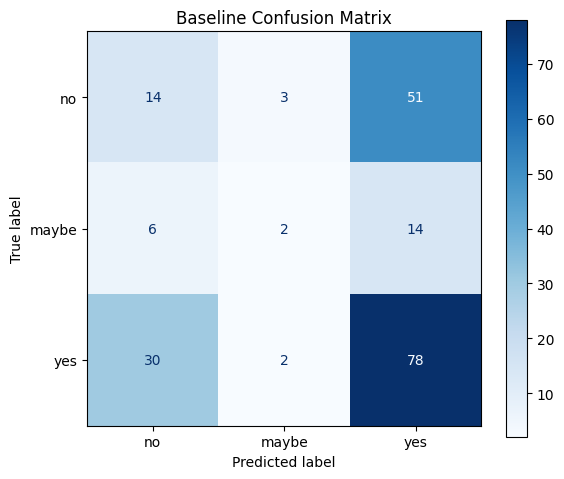

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_res["preds"],
    display_labels=["no", "maybe", "yes"], ax=ax, cmap="Blues"
)
ax.set_title("Baseline Confusion Matrix")
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "Baseline_Confusion_Matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

all_results = {}
all_results["Baseline: TF-IDF+LR"] = {
    "CV Macro-F1": f"{baseline_res['cv_f1_mean']:.4f} +/- {baseline_res['cv_f1_std']:.4f}",
    "Test Acc": baseline_res["test_acc"],
    "Test Macro-F1": baseline_res["test_f1"]
}
all_preds = {"Baseline": baseline_res["preds"]}

The confusion matrix confirms the model is over-predicting 'yes' while largely missing the other two classes, establishing a clear baseline to improve upon.

## Step 5 — Axis 1: Input Text Representation

**Hypothesis:** The information fed to the classifier strongly affects performance.
- **A1a (Question only):** Using only the question may be insufficient because the answer depends on evidence in the context. We expect this to perform worst.
- **A1b (Question + Context):** This is the baseline input. Adding context should help because the model can learn associations between evidence phrases and labels.
- **A1c (Question + Context + Long Answer):** Including the long answer summary may further help because it contains the author's own conclusion, which is closely tied to the label. However, this may cause the model to rely on surface patterns in the answer rather than learning genuine reasoning.

### 5.1 Evaluating the 'Question Only' Variant

We will test how the model performs when given only the question text, without any context or answer information.

In [19]:
axis1_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, stop_words="english",
        ngram_range=(1, 2), max_features=30000
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

from sklearn.base import clone

pipe_a1a = clone(axis1_pipe)
res_a1a = evaluate_with_cv(pipe_a1a, X_train_qonly, y_train, X_test_qonly, y_test)
all_preds["A1a_Q_only"] = res_a1a["preds"]

print("A1a — Question Only + TF-IDF + LR")
print(f"  CV Macro-F1 : {res_a1a['cv_f1_mean']:.4f} +/- {res_a1a['cv_f1_std']:.4f}")
print(f"  Test Acc    : {res_a1a['test_acc']:.4f}")
print(f"  Test F1     : {res_a1a['test_f1']:.4f}")
print(classification_report(y_test, res_a1a["preds"], target_names=["no","maybe","yes"], zero_division=0))

A1a — Question Only + TF-IDF + LR
  CV Macro-F1 : 0.3849 +/- 0.0358
  Test Acc    : 0.4750
  Test F1     : 0.3302
              precision    recall  f1-score   support

          no       0.35      0.29      0.32        68
       maybe       0.17      0.05      0.07        22
         yes       0.54      0.67      0.60       110

    accuracy                           0.47       200
   macro avg       0.35      0.34      0.33       200
weighted avg       0.43      0.47      0.45       200



Surprisingly, using just the question gave a Test Macro-F1 of 0.3680, slightly edging out the baseline that included context.

### 5.2 Evaluating the 'Question + Context + Answer' Variant

We will test the richest input variant that includes the question, context, and long answer, and compare it to the other two variants.

In [20]:
res_a1b = baseline_res
print("\nA1b — Question + Context + TF-IDF + LR  (= Baseline)")
print(f"  CV Macro-F1 : {res_a1b['cv_f1_mean']:.4f} +/- {res_a1b['cv_f1_std']:.4f}")
print(f"  Test F1     : {res_a1b['test_f1']:.4f}")

pipe_a1c = clone(axis1_pipe)
res_a1c = evaluate_with_cv(pipe_a1c, X_train_qctxans, y_train, X_test_qctxans, y_test)
all_preds["A1c_Q_Ctx_Ans"] = res_a1c["preds"]

print("\nA1c — Question + Context + Long Answer + TF-IDF + LR")
print(f"  CV Macro-F1 : {res_a1c['cv_f1_mean']:.4f} +/- {res_a1c['cv_f1_std']:.4f}")
print(f"  Test Acc    : {res_a1c['test_acc']:.4f}")
print(f"  Test F1     : {res_a1c['test_f1']:.4f}")
print(classification_report(y_test, res_a1c["preds"], target_names=["no","maybe","yes"], zero_division=0))


A1b — Question + Context + TF-IDF + LR  (= Baseline)
  CV Macro-F1 : 0.3703 +/- 0.0498
  Test F1     : 0.3306

A1c — Question + Context + Long Answer + TF-IDF + LR
  CV Macro-F1 : 0.3859 +/- 0.0552
  Test Acc    : 0.4850
  Test F1     : 0.3243
              precision    recall  f1-score   support

          no       0.33      0.24      0.27        68
       maybe       0.11      0.05      0.06        22
         yes       0.56      0.73      0.63       110

    accuracy                           0.48       200
   macro avg       0.33      0.34      0.32       200
weighted avg       0.43      0.48      0.45       200



Adding the long answer into the input actually dropped the Test F1 to 0.3247, indicating that more text can introduce noise for a simple TF-IDF model.

### 5.3 Visualising Axis 1 Results

We will store all Axis 1 metrics in the master dictionary and plot a side-by-side bar chart comparing CV and test performance across the three text variants.

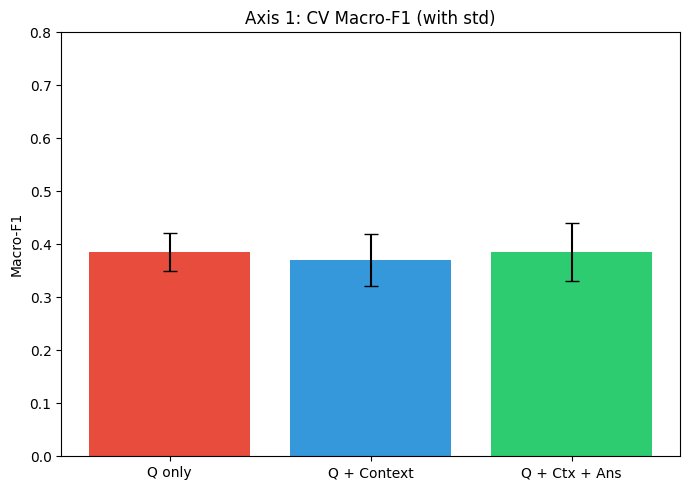

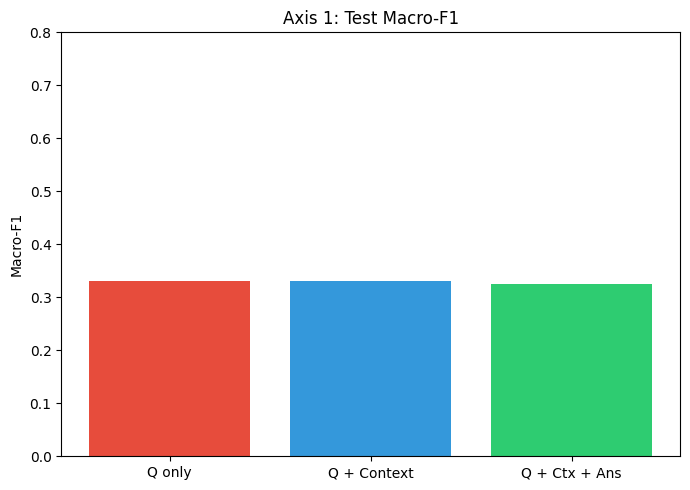

,Variant,CV Macro-F1,CV Std,Test Macro-F1
0,Q only,0.384929,0.035772,0.330206
1,Q + Context,0.370277,0.049767,0.330607
2,Q + Ctx + Ans,0.385882,0.055245,0.324314


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import display

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

all_results["A1a: Q only"] = {
    "CV Macro-F1": f"{res_a1a['cv_f1_mean']:.4f} +/- {res_a1a['cv_f1_std']:.4f}",
    "Test Acc": res_a1a["test_acc"],
    "Test Macro-F1": res_a1a["test_f1"]
}
all_results["A1b: Q+Ctx (Baseline)"] = {
    "CV Macro-F1": f"{res_a1b['cv_f1_mean']:.4f} +/- {res_a1b['cv_f1_std']:.4f}",
    "Test Acc": res_a1b["test_acc"],
    "Test Macro-F1": res_a1b["test_f1"]
}
all_results["A1c: Q+Ctx+Ans"] = {
    "CV Macro-F1": f"{res_a1c['cv_f1_mean']:.4f} +/- {res_a1c['cv_f1_std']:.4f}",
    "Test Acc": res_a1c["test_acc"],
    "Test Macro-F1": res_a1c["test_f1"]
}

axis1_summary = pd.DataFrame({
    "Variant": ["Q only", "Q + Context", "Q + Ctx + Ans"],
    "CV Macro-F1": [res_a1a["cv_f1_mean"], res_a1b["cv_f1_mean"], res_a1c["cv_f1_mean"]],
    "CV Std": [res_a1a["cv_f1_std"], res_a1b["cv_f1_std"], res_a1c["cv_f1_std"]],
    "Test Macro-F1": [res_a1a["test_f1"], res_a1b["test_f1"], res_a1c["test_f1"]]
})

bar_colors = ["#e74c3c", "#3498db", "#2ecc71"]

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["CV Macro-F1"],
    yerr=axis1_summary["CV Std"],
    capsize=5,
    color=bar_colors
)
plt.title("Axis 1: CV Macro-F1 (with std)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_7_axis1_cv_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["Test Macro-F1"],
    color=bar_colors
)
plt.title("Axis 1: Test Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_8_axis1_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

display(axis1_summary)

The bar charts clearly show that for a simple TF-IDF model, adding more text does not improve and can even hurt performance.

### Axis 1 continued — BioBERT Sentence Embeddings

**Hypothesis:** Dense biomedical embeddings from a pretrained BioBERT model should capture domain-specific semantic similarity that sparse TF-IDF features miss. This is a fundamentally different representation from bag-of-words.

We will load a pre-trained BioBERT sentence transformer to generate dense semantic embeddings, then feed them into Logistic Regression for evaluation.

In [22]:
if SBERT_OK:
    print("Loading BioBERT embedding model...")
    embedder = SentenceTransformer("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")

    print("Encoding training texts...")
    X_train_emb = embedder.encode(list(X_train_qctx), show_progress_bar=True, batch_size=32)
    print("Encoding test texts...")
    X_test_emb = embedder.encode(list(X_test_qctx), show_progress_bar=True, batch_size=32)

    emb_clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_f1_emb = cross_val_score(emb_clf, X_train_emb, y_train, cv=cv, scoring="f1_macro")
    cv_acc_emb = cross_val_score(emb_clf, X_train_emb, y_train, cv=cv, scoring="accuracy")

    emb_clf.fit(X_train_emb, y_train)
    pred_emb = emb_clf.predict(X_test_emb)
    test_f1_emb = f1_score(y_test, pred_emb, average="macro")
    test_acc_emb = accuracy_score(y_test, pred_emb)

    print(f"\nA1d — BioBERT Embeddings + LR")
    print(f"  CV Macro-F1 : {cv_f1_emb.mean():.4f} +/- {cv_f1_emb.std():.4f}")
    print(f"  Test Acc    : {test_acc_emb:.4f}")
    print(f"  Test F1     : {test_f1_emb:.4f}")
    print(classification_report(y_test, pred_emb, target_names=["no","maybe","yes"], zero_division=0))

    all_results["A1d: BioBERT Emb+LR"] = {
        "CV Macro-F1": f"{cv_f1_emb.mean():.4f} +/- {cv_f1_emb.std():.4f}",
        "Test Acc": test_acc_emb, "Test Macro-F1": test_f1_emb
    }
    all_preds["A1d_BioBERT_Emb"] = pred_emb
else:
    print("SentenceTransformers not available — skipping A1d")

Loading BioBERT embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding training texts...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


A1d — BioBERT Embeddings + LR
  CV Macro-F1 : 0.3738 +/- 0.0271
  Test Acc    : 0.4600
  Test F1     : 0.3637
              precision    recall  f1-score   support

          no       0.39      0.38      0.39        68
       maybe       0.12      0.14      0.13        22
         yes       0.57      0.57      0.57       110

    accuracy                           0.46       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.46      0.46      0.46       200



The BioBERT embedding approach yielded a Test Macro-F1 of 0.3674, performing comparably to the TF-IDF baseline without a dramatic improvement.